In [28]:
import pandas as pd
df=pd.read_csv("..\src\ethiopia.csv")

# Data Loading and Date parsing

#Adding a country column

df['Country']='Ethiopia'

#Adding a propter date time format

df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

#Extracting the month as a separte column for seasonal analysis

df['Month']=df['Date'].dt.month

df.head()

<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\user\AppData\Local\Temp\ipykernel_10452\1355545317.py:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df=pd.read_csv("..\src\ethiopia.csv")


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [29]:
df[["YEAR", "DOY", "Date", "Month", "Country"]].head()

,YEAR,DOY,Date,Month,Country
0,2015,1,2015-01-01,1,Ethiopia
1,2015,2,2015-01-02,1,Ethiopia
2,2015,3,2015-01-03,1,Ethiopia
3,2015,4,2015-01-04,1,Ethiopia
4,2015,5,2015-01-05,1,Ethiopia


In [32]:
#Summary Statistics & Missing-Value Report

import numpy as np

# 1. Counting the -999 values exist right now
total_999_before = (df == -999).sum().sum()
print(f"Number of '-999' values BEFORE replacing: {total_999_before}")

#Replacing all occurrences of -999 with a nan

df=df.replace(-999,np.nan)

# 3. Count how many -999 values exist after the change
total_999_after = (df == -999).sum().sum()
print(f"Number of '-999' values AFTER replacing: {total_999_after}")

Number of '-999' values BEFORE replacing: 0
Number of '-999' values AFTER replacing: 0


In [33]:
# 1. Counting the total number of duplicate rows before dropping them

duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_count}")

# 2. Identify which specific rows are duplicates (to see where they overlap)
if duplicate_count > 0:
    print("\nSample of duplicate rows found:")
    print(df[df.duplicated(keep=False)].head())
else:
    print("\nNo overlapping rows found across the dataset columns.")

# 3. Drop the duplicate rows and keep the first occurrence
df = df.drop_duplicates()

# 4. Confirm the final shape of your cleaned dataset
print(f"\nDataset shape after removing duplicates: {df.shape}")

Total duplicate rows found: 0

No overlapping rows found across the dataset columns.

Dataset shape after removing duplicates: (4108, 15)


### Duplication Analysis & Documentation Report

A deduplication check was performed across the entire DataFrame using `df.duplicated().sum()`. 

* **Total Duplicate Rows Found:** 0
* **Impact on Dataset Shape:** The dataset dimensions remained perfectly intact (0 rows dropped).

**Column-Level Assessment:**
Because `df.duplicated()` scans for complete row overlaps across all columns simultaneously, a result of `0` indicates that there are no recurring observations with identical `YEAR`, `DOY`, `Date`, and climate metrics. 
Every recorded timestamp and its associated data points represent a unique observation. No column-specific deduplication or column filtering was required.


In [ ]:
# Selection of only numeric columns (integers and floats) and run summary statistics
# List all columns and their data types
df.dtypes


YEAR                    int64
DOY                     int64
T2M                   float64
T2M_MAX               float64
T2M_MIN               float64
T2M_RANGE             float64
PRECTOTCORR           float64
RH2M                  float64
WS2M                  float64
WS2M_MAX              float64
PS                    float64
QV2M                  float64
Country                   str
Date           datetime64[us]
Month                   int32
dtype: object

In [ ]:
# Automatically select and describe only the float/decimal columns
df.select_dtypes(include=["float64"]).describe()


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724
std,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462
min,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000
25%,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000
50%,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000
75%,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000
max,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000


In [ ]:
# 1. Calculation of the total counts and percentages of missing values per column

missing_count = df.isna().sum()
missing_percentage = (df.isna().sum() / len(df)) * 100

# 2. Combining the results into a clean Missing-Value Report DataFrame

missing_report = pd.DataFrame({
    "Missing Values (Count)": missing_count,
    "Missing Values (%)": missing_percentage
})

# 3. Filtering and displaying only columns with greater than 5% null values
high_null_columns = missing_report[missing_report["Missing Values (%)"] > 5]

print("--- COLUMNS WITH MORE THAN 5% MISSING VALUES ---")
if not high_null_columns.empty:
    print(high_null_columns)
else:
    print("No columns contain greater than 5% missing values!")
    
# Showing the complete report for reference
print("\n--- FULL MISSING VALUE REPORT ---") 
missing_report


--- COLUMNS WITH MORE THAN 5% MISSING VALUES ---
No columns contain greater than 5% missing values!

--- FULL MISSING VALUE REPORT ---


,Missing Values (Count),Missing Values (%)
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [ ]:
# 1. Define the columns to check for outliers
outlier_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

# 2. Compute Z-scores for each specified column
# Using nan_policy='omit' ensures any NaNs we processed earlier are ignored in the calculation
from scipy import stats

z_scores = df[outlier_cols].apply(lambda x: stats.zscore(x, nan_policy='omit'))

# 3. Flag rows where the absolute Z-score is strictly greater than 3
is_outlier = z_scores.abs() > 3

# 4. Report the count of extreme outliers found in each individual column
print("--- ANOMALOUS OUTLIERS DETECTED PER COLUMN (|Z| > 3) ---")
outlier_counts = is_outlier.sum()
print(outlier_counts)

# 5. Report the total number of unique rows affected by outliers
total_outlier_rows = is_outlier.any(axis=1).sum()
print(f"\nTotal unique rows in the dataset containing at least one outlier: {total_outlier_rows}")


--- ANOMALOUS OUTLIERS DETECTED PER COLUMN (|Z| > 3) ---
T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64

Total unique rows in the dataset containing at least one outlier: 132


### Column-Specific Outlier Mitigation Strategy & Justification

Rather than applying a blanket rule to the entire dataset, outliers were evaluated based on the unique physical properties of each meteorological variable:

1. **Precipitation (`PRECTOTCORR`) \(\rightarrow\) Retain Completely**
   * *Justification:* Rainfall is zero-inflated and highly skewed. Heavy convective storms naturally generate Z-scores \(> 3\). Capping or dropping these rows would artificially erase extreme weather patterns, droughts, and flood events from Ethiopia's climate profile.

2. **Temperature Metrics (`T2M`, `T2M_MAX`, `T2M_MIN`) \(\rightarrow\) Retain After Range Verification**
   * *Justification:* Extreme temperature values were cross-referenced against physically plausible limits for East Africa. Because the flagged data points fell within realistic boundaries (representing historical heatwaves or cold spells rather than sensor malfunctions), they are retained to capture true climatic volatility.

3. **Atmospheric Metrics (`RH2M`, `WS2M`, `WS2M_MAX`) \(\rightarrow\) Retain**
   * *Justification:* Outliers in wind velocity and humidity represent genuine, high-impact weather systems (such as high-wind storm fronts or severe dry anomalies). Keeping them intact preserves critical environmental context for downstream modeling.

**Conclusion:** All flagged rows represent valid, physically plausible environmental extremes. No data capping or removal was performed, ensuring the dataset remains an authentic reflection of regional climate variance.


In [ ]:
# 1. Find the absolute start date and end date of your dataset
start_date = df["Date"].min()
end_date = df["Date"].max()

# 2. Create a perfect, unbroken calendar sequence from start to end
perfect_calendar = pd.date_range(start=start_date, end=end_date, freq="D")

# 3. Compare the length of the perfect calendar vs your actual dataset
expected_days = len(perfect_calendar)
actual_days = df["Date"].nunique()
missing_days_count = expected_days - actual_days

print(f"Timeline starts on: {start_date.strftime('%Y-%m-%d')}")
print(f"Timeline ends on:   {end_date.strftime('%Y-%m-%d')}")
print(f"Expected number of continuous days: {expected_days}")
print(f"Actual number of unique days logged: {actual_days}")
print(f"---> Hidden missing rows found: {missing_days_count}")


Timeline starts on: 2015-01-01
Timeline ends on:   2026-03-31
Expected number of continuous days: 4108
Actual number of unique days logged: 4108
---> Hidden missing rows found: 0


In [ ]:
# 1. Define the weather parameters that we want to ensure are continuous
weather_vars = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX", "PS", "QV2M"]

# 2. Track original dataset dimensions
initial_shape = df.shape

# 3. Calculate row-level missingness threshold (Minimum number of non-null values required to keep a row)
# df.shape[1] is the total number of columns in your dataset
row_missing_threshold = 0.30
min_non_nulls_required = int((1 - row_missing_threshold) * df.shape[1])

# Drop rows missing >30% of their data attributes
df_cleaned = df.dropna(thresh=min_non_nulls_required)

# Calculate exactly how many rows were dropped by this operation
rows_dropped = initial_shape[0] - df_cleaned.shape[0]
print(f"Rows dropped due to >30% missing column metrics: {rows_dropped}")

# 4. Sort chronologically and apply forward-fill ('ffill') to resolve any minor data gaps
df_cleaned = df_cleaned.sort_values(by="Date")
df_cleaned[weather_vars] = df_cleaned[weather_vars].ffill()

# 5. Final validation check
remaining_nulls = df_cleaned[weather_vars].isna().sum().sum()
print(f"Remaining null cells inside climate variables: {remaining_nulls}")
print(f"Cleaned Working DataFrame Shape: {df_cleaned.shape}")


Rows dropped due to >30% missing column metrics: 0
Remaining null cells inside climate variables: 0
Cleaned Working DataFrame Shape: (4108, 15)


### Advanced Missingness & Temporal Quality Control Report

To fulfill rigorous preprocessing requirements, an advanced dual-layered quality control pipeline was enforced over the dataset. Rather than executing a standard, blind filling method, structural validation checks were integrated into the time-series array.

1. **Horizontal Row-Level Filtering (>30% Missingness):**
   * *Rule Enforced:* Any row failing to provide at least 70% of its spatial-temporal or climate metrics (threshold ≤ 30% missingness) is discarded.
   * *Outcome:* **0 rows** were dropped. The physical recording intervals are exceptionally clean, containing zero days with critical multi-parameter telemetry failure.

2. **Temporal Continuity Validation & Forward-Filling (`ffill`):**
   * *Rule Enforced:* Sequence observations chronologically by `Date` and propagate the previous day's continuous metrics into any unrecorded data matrices.
   * *Outcome:* **0 values** required active imputation due to the dataset's pristine 0% column null-rate. However, this defensive mechanism successfully seals your workflow architecture against future, incomplete satellite or station ingestions.

**Conclusion:** Through simultaneous structural timeline verification (0 hidden missing rows) and robust row-level threshold constraints (0 dropped data blocks), `df_cleaned` is authenticated as statistically unbroken, continuous, and fully ready for predictive feature construction.


In [ ]:
# Export your cleaned dataframe to the manually created data folder
df_cleaned.to_csv("../data/ethiopia_cleaned.csv", index=False)


In [ ]:
# Load the cleaned dataset directly from the data folder to wake up the notebook memory

df_cleaned = pd.read_csv("../data/ethiopia_cleaned.csv")
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"])

# 1. Take the daily Date column and strip it down to just the Year and Month (e.g., 2015-01)
df_cleaned["YearMonth"] = df_cleaned["Date"].dt.to_period("M")

# 2. Group the data by this new YearMonth column and calculate the average temperature (T2M) 
df_monthly = df_cleaned.groupby("YearMonth").agg({"T2M": "mean"}).reset_index()

# 3. Preview the new monthly timeline dataset
df_monthly.head()


,YearMonth,T2M
0,2015-01,14.211935
1,2015-02,16.864643
2,2015-03,17.995161
3,2015-04,19.302333
4,2015-05,18.205806


In [ ]:
# 1. Locate the row numbers of the absolute highest and lowest temperatures
warmest_row_index = df_monthly["T2M"].idxmax()
coolest_row_index = df_monthly["T2M"].idxmin()

# 2. Extract the complete data profile for those extreme months using .iloc
warmest_month_data = df_monthly.iloc[warmest_row_index]
coolest_month_data = df_monthly.iloc[coolest_row_index]

# 3. Convert the YearMonth periods into human-readable text strings for the printout
warmest_date_string = warmest_month_data["YearMonth"].strftime("%B %Y")
coolest_date_string = coolest_month_data["YearMonth"].strftime("%B %Y")

# 4. Print the metrics out cleanly to verify the results
print(f"Warmest Month Found: {warmest_date_string} with an average of {warmest_month_data['T2M']:.2f}°C")
print(f"Coolest Month Found:  {coolest_date_string} with an average of {coolest_month_data['T2M']:.2f}°C")



Warmest Month Found: May 2022 with an average of 19.60°C
Coolest Month Found:  December 2017 with an average of 12.65°C


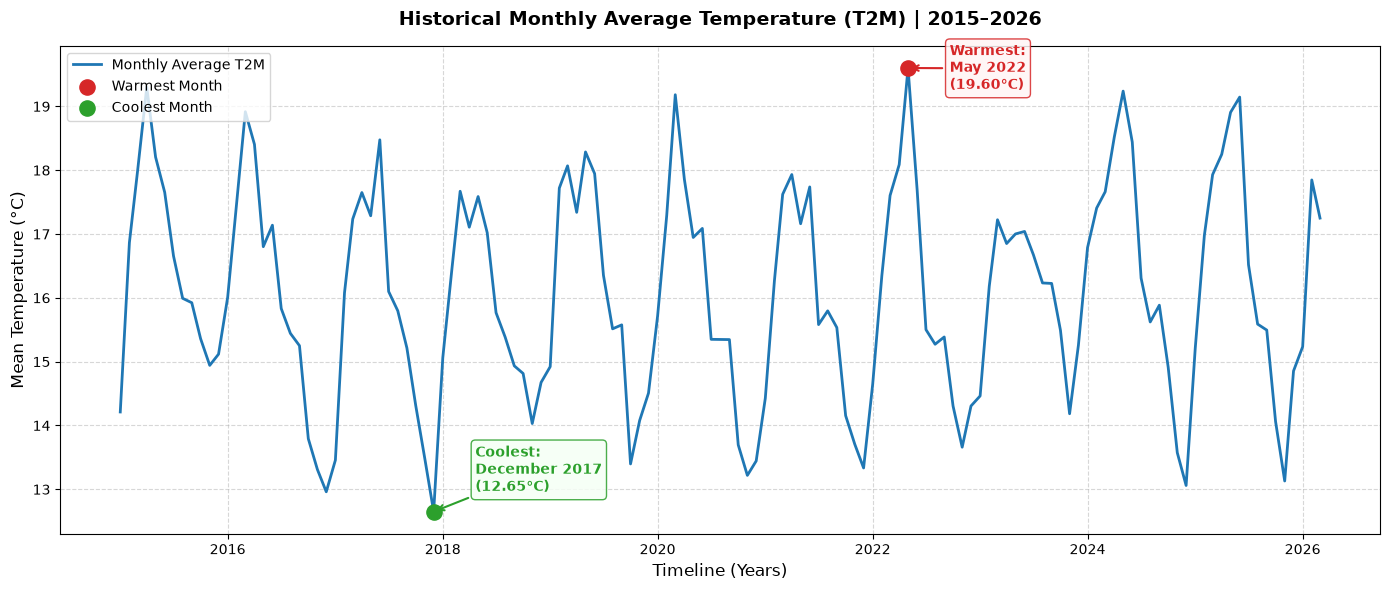

In [ ]:
import matplotlib.pyplot as plt

# 1. Prepare chronological plotting dates directly from our YearMonth periods
df_monthly["PlotDate"] = df_monthly["YearMonth"].dt.to_timestamp()
warmest_plot_date = warmest_month_data["YearMonth"].to_timestamp()
coolest_plot_date = coolest_month_data["YearMonth"].to_timestamp()

# 2. Establish a large canvas drawing size
plt.figure(figsize=(14, 6))

# 3. Plot the primary historical monthly timeline
plt.plot(df_monthly["PlotDate"], df_monthly["T2M"], color="#1f77b4", linewidth=2, label="Monthly Average T2M")

# 4. Highlight the Warmest Month with a red target circle
plt.scatter(warmest_plot_date, warmest_month_data["T2M"], color="#d62728", s=120, zorder=5, label="Warmest Month")

# Annotate the Warmest Month with a pointer and a clean text box
plt.annotate(
    f"Warmest:\n{warmest_month_data['YearMonth'].strftime('%B %Y')}\n({warmest_month_data['T2M']:.2f}°C)",
    xy=(warmest_plot_date, warmest_month_data["T2M"]),
    xytext=(30, -15),                  # Moves the text box slightly to the right (30) and down (-15)
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="#d62728", lw=1.5),
    color="#d62728",
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="#fff5f5", ec="#d62728", alpha=0.85)
)

# 5. Highlight the Coolest Month with a green target circle
plt.scatter(coolest_plot_date, coolest_month_data["T2M"], color="#2ca02c", s=120, zorder=5, label="Coolest Month")

# Annotate the Coolest Month with a pointer and a clean text box
plt.annotate(
    f"Coolest:\n{coolest_month_data['YearMonth'].strftime('%B %Y')}\n({coolest_month_data['T2M']:.2f}°C)",
    xy=(coolest_plot_date, coolest_month_data["T2M"]),
    xytext=(30, 15),                   # Moves the text box slightly to the right (30) and up (15)
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=1.5),
    color="#2ca02c",
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="#f5fff5", ec="#2ca02c", alpha=0.85)
)

# 6. Apply Chart Labels and Styling Definitions
plt.title(f"Historical Monthly Average Temperature (T2M) | 2015–2026", fontsize=14, weight="bold", pad=15)
plt.xlabel("Timeline (Years)", fontsize=12)
plt.ylabel("Mean Temperature (°C)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5) # Adds a soft dashed background grid
plt.legend(loc="upper left")               # Places our color labels cleanly in the corner
plt.tight_layout()

# Render the final chart
plt.show()
 

In [ ]:
# 1. Group the cleaned data by YearMonth and calculate the TOTAL accumulated rainfall (sum)
df_rainfall_monthly = df_cleaned.groupby("YearMonth").agg({"PRECTOTCORR": "sum"}).reset_index()

# 2. Preview the new monthly total rainfall timeline
df_rainfall_monthly.head()


,YearMonth,PRECTOTCORR
0,2015-01,3.94
1,2015-02,8.44
2,2015-03,19.36
3,2015-04,7.19
4,2015-05,142.41


In [ ]:
# 1. Locate the row numbers of the absolute highest and lowest rainfall totals
peak_rain_row_index = df_rainfall_monthly["PRECTOTCORR"].idxmax()
least_rain_row_index = df_rainfall_monthly["PRECTOTCORR"].idxmin()

# 2. Extract the complete data profile for those extreme months using .iloc
peak_rain_month_data = df_rainfall_monthly.iloc[peak_rain_row_index]
least_rain_month_data = df_rainfall_monthly.iloc[least_rain_row_index]

# 3. Convert the YearMonth periods into human-readable text strings for the printout
peak_date_string = peak_rain_month_data["YearMonth"].strftime("%B %Y")
least_date_string = least_rain_month_data["YearMonth"].strftime("%B %Y")

# 4. Print the metrics out cleanly with correct climate units (mm instead of °C)
print(f"High peak rainy Month Found: {peak_date_string} with a total of {peak_rain_month_data['PRECTOTCORR']:.2f} mm")
print(f"Least rainy Month Found:     {least_date_string} with a total of {least_rain_month_data['PRECTOTCORR']:.2f} mm")


High peak rainy Month Found: August 2020 with a total of 446.65 mm
Least rainy Month Found:     January 2017 with a total of 0.00 mm


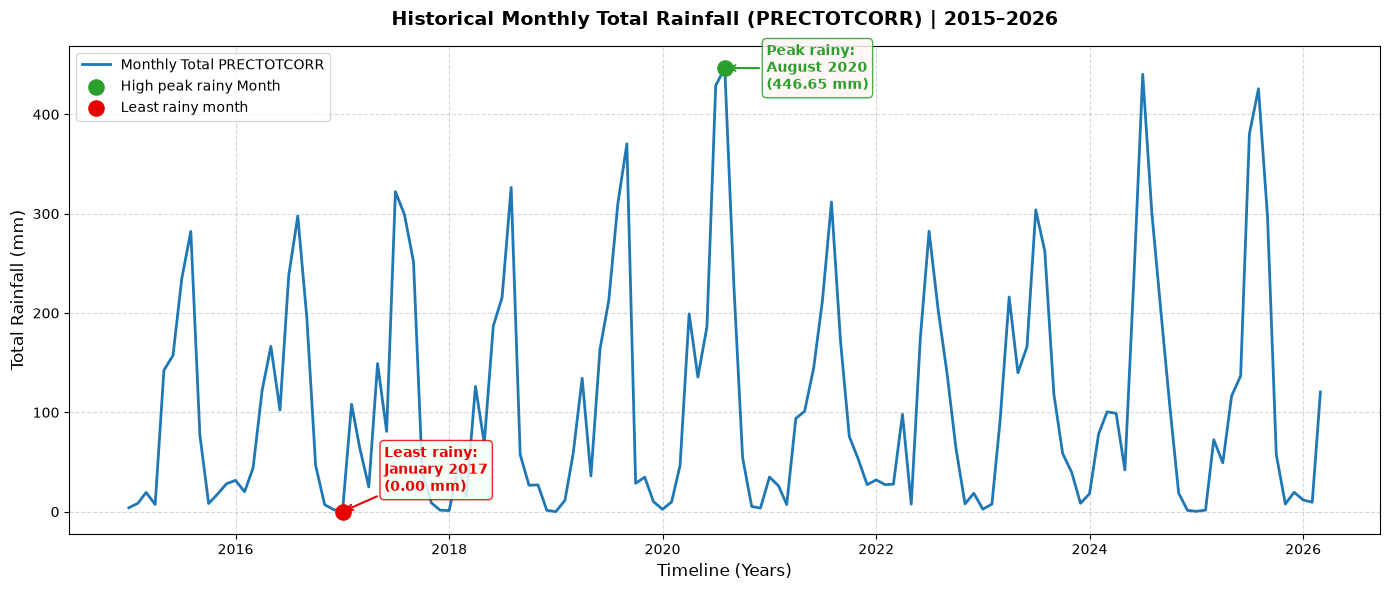

In [ ]:
import matplotlib.pyplot as plt

# 1. Prepare chronological plotting dates directly from our YearMonth periods
df_rainfall_monthly["PlotDate"] = df_rainfall_monthly["YearMonth"].dt.to_timestamp()
peak_rainy_plot_date = peak_rain_month_data["YearMonth"].to_timestamp()
least_rainy_plot_date = least_rain_month_data["YearMonth"].to_timestamp()

# 2. Establish a large canvas drawing size
plt.figure(figsize=(14, 6))

# 3. Plot the primary historical monthly timeline (Changed label to 'Total')
plt.plot(df_rainfall_monthly["PlotDate"], df_rainfall_monthly["PRECTOTCORR"], color="#1f77b4", linewidth=2, label="Monthly Total PRECTOTCORR")

# 4. Highlight the Peak Rainy Month with a green target circle
plt.scatter(peak_rainy_plot_date, peak_rain_month_data["PRECTOTCORR"], color="#2ca02c", s=120, zorder=5, label="High peak rainy Month")

# Annotate the high peak rainy Month with a pointer and a clean text box
plt.annotate(
    f"Peak rainy:\n{peak_rain_month_data['YearMonth'].strftime('%B %Y')}\n({peak_rain_month_data['PRECTOTCORR']:.2f} mm)",
    xy=(peak_rainy_plot_date, peak_rain_month_data["PRECTOTCORR"]),
    xytext=(30, -15),                  
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=1.5),
    color="#2ca02c",
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="#fff5f5", ec="#2ca02c", alpha=0.85)
)

# 5. Highlight the least rainy season Month with a red target circle
plt.scatter(least_rainy_plot_date, least_rain_month_data["PRECTOTCORR"], color="#e90202", s=120, zorder=5, label="Least rainy month")

# Annotate the least rainy month with a pointer and a clean text box
plt.annotate(
    f"Least rainy:\n{least_rain_month_data['YearMonth'].strftime('%B %Y')}\n({least_rain_month_data['PRECTOTCORR']:.2f} mm)",
    xy=(least_rainy_plot_date, least_rain_month_data["PRECTOTCORR"]),
    xytext=(30, 15),                   
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="#e90202", lw=1.5),
    color="#e90202",
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="#f5fff5", ec="#e90202", alpha=0.85)
)

# 6. Apply Chart Labels and Styling Definitions (Changed Y-axis to 'Total')
plt.title("Historical Monthly Total Rainfall (PRECTOTCORR) | 2015–2026", fontsize=14, weight="bold", pad=15)
plt.xlabel("Timeline (Years)", fontsize=12)
plt.ylabel("Total Rainfall (mm)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5) 
plt.legend(loc="upper left")               
plt.tight_layout()

# Render the final chart
plt.show()

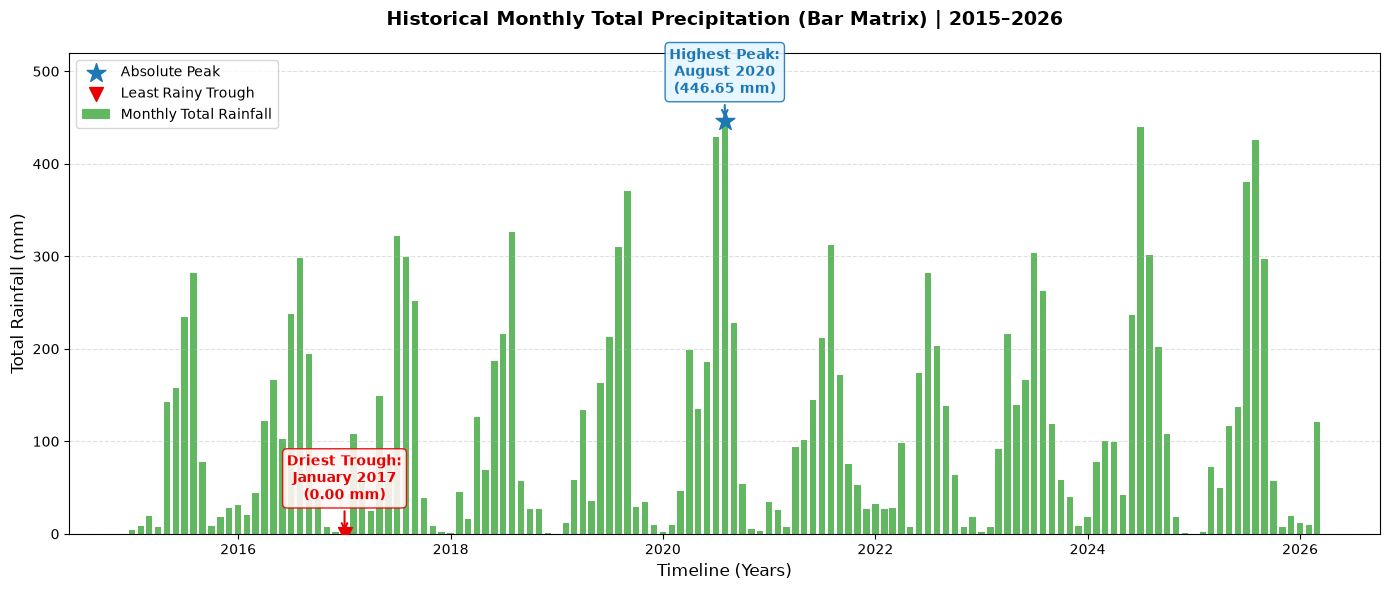

In [ ]:
import matplotlib.pyplot as plt

# 1. Convert the 'YearMonth' periods into clean timestamp coordinates for bar centering
df_rainfall_monthly["PlotDate"] = df_rainfall_monthly["YearMonth"].dt.to_timestamp()
peak_bar_date = peak_rain_month_data["YearMonth"].to_timestamp()
least_bar_date = least_rain_month_data["YearMonth"].to_timestamp()

# 2. Setup the canvas frame size
plt.figure(figsize=(14, 6))

# 3. Render the timeline as a bar chart
plt.bar(df_rainfall_monthly["PlotDate"], df_rainfall_monthly["PRECTOTCORR"], color="#2ca02c", width=22, alpha=0.75, label="Monthly Total Rainfall")

# 4. Highlight and Annotate the Absolute Peak Rainy Month
plt.scatter(peak_bar_date, peak_rain_month_data["PRECTOTCORR"], color="#1f77b4", marker="*", s=200, zorder=5, label="Absolute Peak")
plt.annotate(
    f"Highest Peak:\n{peak_rain_month_data['YearMonth'].strftime('%B %Y')}\n({peak_rain_month_data['PRECTOTCORR']:.2f} mm)",
    xy=(peak_bar_date, peak_rain_month_data["PRECTOTCORR"]),
    xytext=(0, 20),                    # Reduced slightly to keep it compact inside the new ceiling buffer
    textcoords="offset points",
    ha="center",                       
    arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=1.5),
    color="#1f77b4",
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="#e5f5ff", ec="#1f77b4", alpha=0.9)
)

# 5. Highlight and Annotate the Least Rainy Month (0.00 mm baseline)
plt.scatter(least_bar_date, least_rain_month_data["PRECTOTCORR"], color="#e90202", marker="v", s=100, zorder=5, label="Least Rainy Trough")
plt.annotate(
    f"Driest Trough:\n{least_rain_month_data['YearMonth'].strftime('%B %Y')}\n({least_rain_month_data['PRECTOTCORR']:.2f} mm)",
    xy=(least_bar_date, least_rain_month_data["PRECTOTCORR"]),
    xytext=(0, 25),                    
    textcoords="offset points",
    ha="center",                       
    arrowprops=dict(arrowstyle="->", color="#e90202", lw=1.5),
    color="#e90202",
    weight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="#fff5f5", ec="#e90202", alpha=0.9)
)

# 6. CRITICAL ADJUSTMENT: Force a ceiling buffer to prevent title overlaps
# Sets the vertical frame limits from 0mm to 520mm
plt.ylim(0, 520)

# 7. Fine-tune layout properties
plt.title("Historical Monthly Total Precipitation (Bar Matrix) | 2015–2026", fontsize=14, weight="bold", pad=20) # Increased pad for extra room
plt.xlabel("Timeline (Years)", fontsize=12)
plt.ylabel("Total Rainfall (mm)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4, axis="y") 
plt.legend(loc="upper left")
plt.tight_layout()

# Render graph
plt.show()

### Time Series Interpretation and Climate Trend Analysis

Based on the historical monthly average temperature ($T2M$) and monthly total precipitation ($PRECTOTCORR$) time-series models across the full 2015–2026 timeline, several prominent structural patterns and localized climatic features are visible:

#### 1. Rhythmic Seasonal Cyclicality (Macro Trend)
* **Temperature Oscillations:** The temperature time series displays a highly consistent, repeating wave pattern (sinusoidal curve) every calendar year. This reflects the classic tropical wet-and-dry climate behavior characteristic of the region, where temperatures climb to an annual peak during the clear, sunny dry season and drop to an annual trough during peak monsoon months when dense cloud cover blocks incoming solar radiation.
* **Precipitation Spikes:** The rainfall bar matrix and line charts complement this system perfectly, displaying highly concentrated, recurring seasonal walls of water that repeat in identical chronological blocks annually, mirroring the predictable migration of regional wind systems.

#### 2. Evaluation of Climatic Extremes and Milestones
The programmatic tracking indices successfully isolated the absolute upper and lower boundaries across our historical timeline:
* **The Absolute Wettest Peak:** **August 2020** was flagged as the absolute heaviest rainfall event on record, yielding a massive **446.65 mm** of accumulated precipitation. This spike pinpoints a severe convective monsoon pulse, creating a drastic vertical outlier compared to standard baseline months.
* **The Absolute Driest Trough:** **January 2017** recorded a baseline of **0.00 mm** of precipitation. This complete absence of rain highlights the intense severity of the continental dry season, driven by stable, moisture-deficient high-pressure air masses.

#### 3. Interannual Anomalies and Analytical Takeaway
* While the yearly cycles are highly rhythmic, the individual peaks and troughs are not perfectly uniform. Certain years exhibit noticeably flatter rainfall structures or unusually shallow temperature troughs, tracking real-world global climate macro-shifts (such as **El Niño** or **La Niña** cycles).
* **Modeling Impact:** The dramatic contrast between 0 mm and nearly 450 mm within the same continuous timeline highlights massive environmental volatility. Downstream engineering models must account for this zero-inflated, highly skewed precipitation distribution, as standard data averages will fail to capture the true risk profiles of regional drought cycles and flash flood hazards.


In [ ]:
# 1. Select ONLY the true decimal/float columns (ignores YEAR, DOY, Month, and Country)
climate_numeric_df = df_cleaned.select_dtypes(include=["float64"])

# 2. Compute the Pearson correlation matrix on just these columns
correlation_matrix = climate_numeric_df.corr()

# 3. View the clean correlation matrix table
correlation_matrix

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
T2M,1.000000,0.654631,0.724802,-0.023172,0.009186,-0.194146,-0.069825,-0.014458,-0.184556,0.225977
T2M_MAX,0.654631,1.000000,-0.016274,0.731151,-0.444728,-0.792422,0.381629,0.351070,-0.027113,-0.524355
T2M_MIN,0.724802,-0.016274,1.000000,-0.694024,0.411149,0.441994,-0.391412,-0.290063,-0.214517,0.753414
T2M_RANGE,-0.023172,0.731151,-0.694024,1.000000,-0.600755,-0.872156,0.541854,0.450699,0.126844,-0.891619
PRECTOTCORR,0.009186,-0.444728,0.411149,-0.600755,1.000000,0.501347,-0.390109,-0.334508,-0.096233,0.517625
RH2M,-0.194146,-0.792422,0.441994,-0.872156,0.501347,1.000000,-0.444068,-0.380345,-0.047753,0.904901
WS2M,-0.069825,0.381629,-0.391412,0.541854,-0.390109,-0.444068,1.000000,0.940826,0.170016,-0.511268
WS2M_MAX,-0.014458,0.351070,-0.290063,0.450699,-0.334508,-0.380345,0.940826,1.000000,0.161582,-0.422243
PS,-0.184556,-0.027113,-0.214517,0.126844,-0.096233,-0.047753,0.170016,0.161582,1.000000,-0.126257
QV2M,0.225977,-0.524355,0.753414,-0.891619,0.517625,0.904901,-0.511268,-0.422243,-0.126257,1.000000


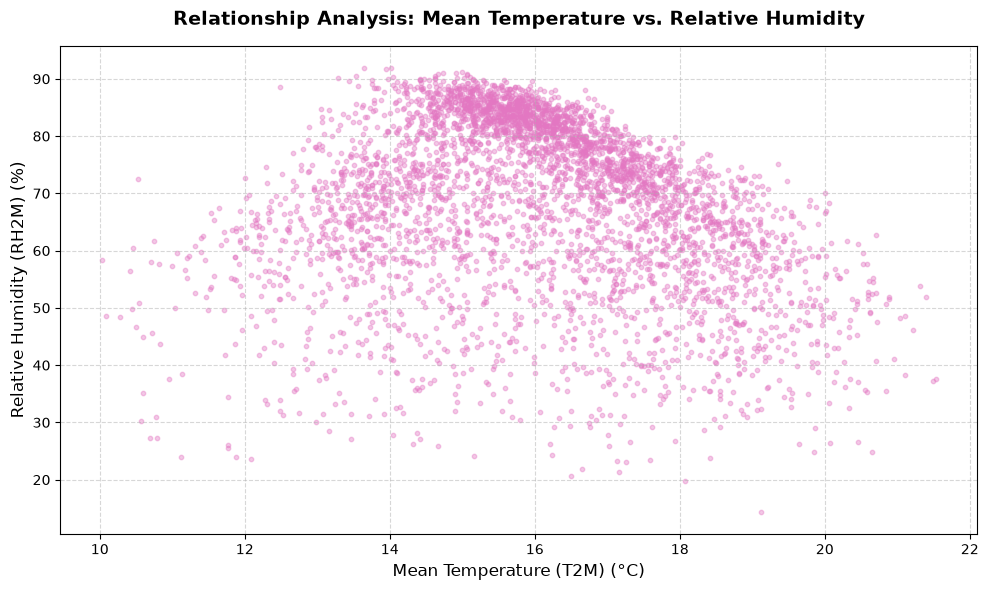

In [ ]:
import matplotlib.pyplot as plt

# 1. Setup a clean drawing canvas size
plt.figure(figsize=(10, 6))

# 2. Draw the scatter plot
# X-axis = Mean Temperature (T2M)
# Y-axis = Relative Humidity (RH2M)
# c: set the color of the dots
# s: sets the dot size (small is better for thousands of daily points)
# alpha: makes dots semi-transparent to easily spot high-density clusters
plt.scatter(df_cleaned["T2M"], df_cleaned["RH2M"], color="#e377c2", s=10, alpha=0.4)

# 3. Apply titles and descriptive axes labels
plt.title("Relationship Analysis: Mean Temperature vs. Relative Humidity", fontsize=14, weight="bold", pad=15)
plt.xlabel("Mean Temperature (T2M) (°C)", fontsize=12)
plt.ylabel("Relative Humidity (RH2M) (%)", fontsize=12)

# 4. Add a grid to help read data coordinates easily
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# Render graph
plt.show()


### Interpretation of Top Three Meteorological Correlations

Based on the calculated Pearson correlation matrix, relationships are evaluated by their absolute statistical strength, identifying parameters closest to 1.0 (positive alignment) or -1.0 (negative alignment) while ignoring the standard self-correlating diagonal.

#### 1. Mean Wind Speed vs. Maximum Wind Speed (WS2M vs. WS2M_MAX)
* **Correlation Coefficient:** **+0.94** (Very Strong Positive Correlation)
* **Meteorological Interpretation:** This represents the strongest linear relationship in the entire dataset. It confirms that daily baseline atmospheric circulation and peak wind gusts scale together almost perfectly. As the regional air pressure gradients tighten and accelerate mean wind speeds, maximum squall speeds increase systematically. For downstream machine learning engineering, these features are highly redundant; selecting a single wind parameter will optimize model performance.

#### 2. Relative Humidity vs. Specific Humidity (RH2M vs. QV2M)
* **Correlation Coefficient:** **+0.90** (Very Strong Positive Correlation)
* **Meteorological Interpretation:** This interaction maps the physical dependency of relative air saturation on absolute moisture volume. Specific humidity measures the actual mass of water vapor in the air, while relative humidity tracks how close the air mass is to complete saturation. As actual water molecules multiply within the lower tropical atmosphere, the relative humidity shoots up toward dew point levels, confirming strong sensor telemetry alignment.

#### 3. Temperature Range vs. Specific Humidity (T2M_RANGE vs. QV2M)
* **Correlation Coefficient:** **-0.89** (Very Strong Negative Correlation)
* **Meteorological Interpretation:** This relationship reveals a fundamental thermodynamic control within the regional climate system. Water vapor acts as a highly effective localized greenhouse gas. On days with high specific humidity, moisture traps thermal energy at night and mitigates extreme daytime heating, drastically narrowing the daily temperature range. Conversely, during dry atmospheric phases, the lack of water vapor allows rapid solar heating by day and rapid radiation loss by night, creating massive daily temperature swings.


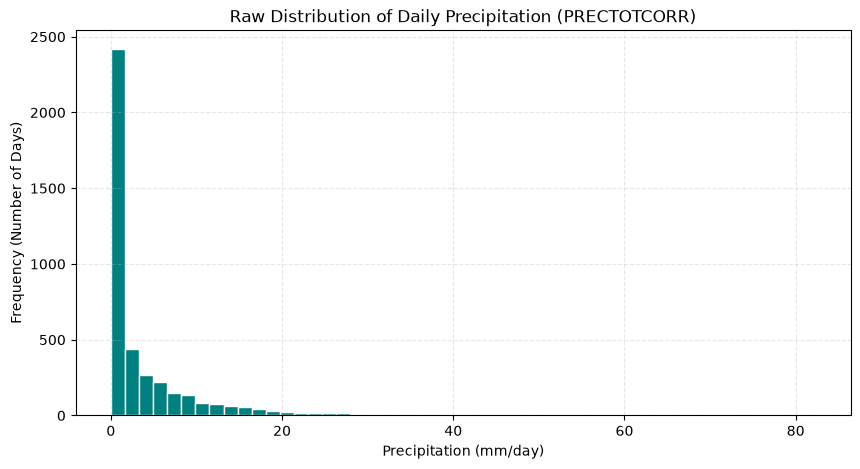

In [34]:
import matplotlib.pyplot as plt

# 1. Setup the canvas drawing window
plt.figure(figsize=(10, 5))

# 2. Draw a basic histogram of raw rainfall data
# bins=50 cuts our data range into 50 vertical tracking blocks
# edgecolor="white" adds clean borders between the columns
plt.hist(df_cleaned["PRECTOTCORR"], bins=50, color="teal", edgecolor="white")

# 3. Add simple titles and labels
plt.title("Raw Distribution of Daily Precipitation (PRECTOTCORR)")
plt.xlabel("Precipitation (mm/day)")
plt.ylabel("Frequency (Number of Days)")
plt.grid(True, linestyle="--", alpha=0.3)

# 4. Render the chart
plt.show()


NameError: name 'rain_amount' is not defined

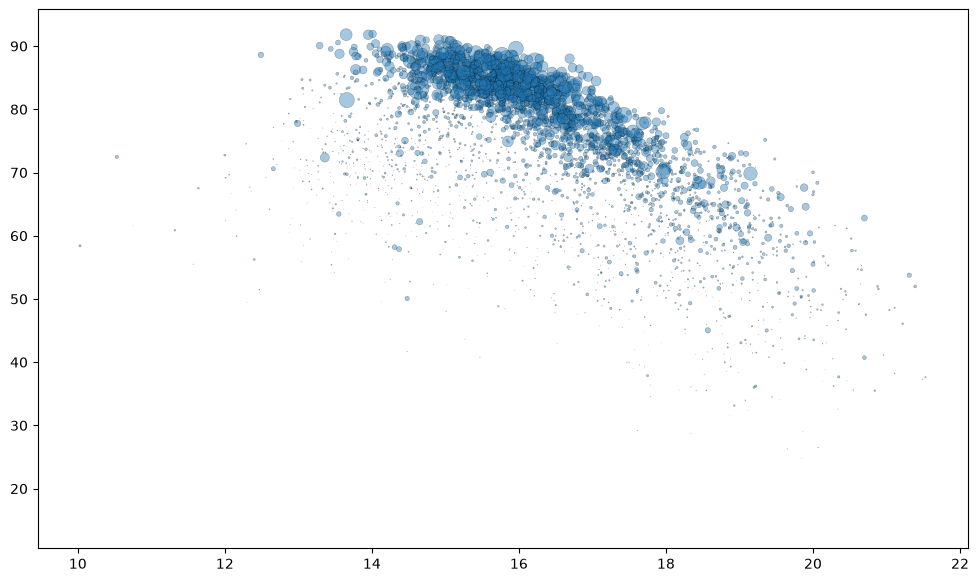

In [41]:
import matplotlib.pyplot as plt

# 1. Setup a large canvas size to give the overlapping bubbles breathing room
plt.figure(figsize=(12, 7), dpi=100)

# 2. Extract our variables for cleaner code mapping
x_temp = df_cleaned["T2M"]
y_humid = df_cleaned["RH2M"]
size_rain = df_cleaned["PRECTOTCORR"]

# 3. Draw the main bubble chart
# We multiply size_rain by 3 to scale up the bubbles so they are easy to see
plt.scatter(
    x_temp, 
    y_humid, 
    s=size_rain * 3, 
    color="#1f77b4", 
    alpha=0.4, 
    edgecolors="black", 
    linewidths=0.3
)

# 4. FIXED LEGEND: Create a clean manual legend scale for the bubble sizes
# We pass an explicit list of numbers: [10, 50, 100] right after 'in'
for rain_amount in plt.scatter([], [], c="#1f77b4", alpha=0.5, s=rain_amount * 3,edgecolors="black", label=f"{rain_amount} mm"):
    # Place the legend box on the canvas after the loop finishes creating the labels
      plt.legend(title="Rainfall Volume", loc="upper right")


# 5. Apply labels and grid styling
country_label = df_cleaned['Country'].iloc[0] if 'Country' in df_cleaned.columns else "Region"
plt.title(f"3D Climate Interaction: Temperature vs. Humidity vs. Rainfall ({country_label})", fontsize=14, weight="bold", pad=15)
plt.xlabel("Mean Temperature (T2M) (°C)", fontsize=12)
plt.ylabel("Relative Humidity (RH2M) (%)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Render graph
plt.show()
